# Modeling — xwOBAcon LR (`xwobacon`)

Linear-regression **control model** for expected damage on contact.

**Prerequisites:** `03_feature_engineering.ipynb`

Production counterpart: **`09_modeling_xwobacon_rf.ipynb`**.

## 1. Target & sample

**Target:** `xwobacon` on balls in play with non-null Statcast xwOBA.

**Filter:** BIP descriptions only (`contact_only`).

## Architecture — apples-to-apples control for RF models

These **logistic / linear baselines** use the **same feature space, pitch-type schema, and chronological split** as the production Random Forest pipeline (`05`, `07`, `09`).

| Split | Dates | Purpose |
|-------|-------|---------|
| **Train** | Mar–Jul 2025 (`game_date < 2025-08-01`) | Fit models |
| **Validation** | Aug 2025 | Forward feature-group selection only |
| **Test** | Sep 2025 | Locked holdout — final metrics once |

**Batter signal:** season-to-date rolling metrics (`swing_pct`, `whiff_pct`, `z_swing_pct`, `o_swing_pct`, `z_whiff_pct`, `o_whiff_pct`) — no `batter_id` or `batter_te`.

**Platoon:** `same_handed`

**Pitch physics (three groups):** `pitch_movement` (`norm_hb`, `norm_ivb`) → `pitcher_delivery` (release point, extension, `p_throws_L`) → `pitch_quality` (`release_speed`, `release_spin_rate`).

**Pitch types:** all **10** competitive Statcast codes (`COMPETITIVE_PITCH_TYPES`) via one-hot `pitch_*` columns.

**Swing definition:** full swings only — `foul_bunt` and `missed_bunt` are takes, not swings.


## 2. Process

| Step | Choice |
|------|--------|
| **Sample** | BIP with valid `xwobacon` |
| **Baseline features** | `is_in_zone`, `miss_dist_in`, `center_dist_in` |
| **Candidate groups** | `pitch_type` → `pitch_quality` → `count` → `batter_rolling` → `bat_tracking` → `pitch_movement` → `pitcher_delivery` → `attack_zone` → `base_state` → `platoon` |
| **Model** | `LinearRegression`, numeric features scaled |
| **Selection metric** | August validation RMSE; keep if gain ≥ **MIN_GAIN_RMSE (0.002)** wOBA points |
| **Group order** | High-signal sequence with `bat_tracking` after `batter_rolling` |
| **Final evaluation** | September test once |

Logic: `src/xwobacon_modeling.py`.

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import Markdown, display

NB_DIR = Path.cwd().resolve()
ROOT = NB_DIR.parent if NB_DIR.name == "notebooks" else NB_DIR
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

MODELING_FILE = ROOT / "data" / "modeling_frame_2025.parquet"
if not MODELING_FILE.exists():
    raise FileNotFoundError(
        f"Run 03_feature_engineering.ipynb first — missing {MODELING_FILE}"
    )

import importlib
import src.feature_engineering as feature_engineering
import src.xwobacon_modeling as xwobacon_modeling

importlib.reload(feature_engineering)
importlib.reload(xwobacon_modeling)

from src.xwobacon_modeling import (
    BASELINE_FEATURES,
    FEATURE_GROUP_ORDER,
    FEATURE_GROUPS,
    MIN_GAIN_RMSE,
    TARGET,
    TRAIN_END,
    VAL_END,
    chronological_split,
    contact_only,
    coefficient_frame,
    forward_select_feature_groups,
    results_table,
    train_master_model,
    xwobacon_target_definition,
)

frame = pd.read_parquet(MODELING_FILE)
train, val, test = chronological_split(frame)
train_bip = contact_only(train)
val_bip = contact_only(val)
test_bip = contact_only(test)

display(Markdown(xwobacon_target_definition()))
print(f"BIP rows — train: {len(train_bip):,} | val: {len(val_bip):,} | test: {len(test_bip):,}")
print(
    f"xwOBAcon mean — train: {train_bip[TARGET].mean():.3f} | "
    f"val: {val_bip[TARGET].mean():.3f} | test: {test_bip[TARGET].mean():.3f}"
)
print(f"Train: Mar–Jul (< {TRAIN_END.date()}) | Val: Aug | Test: Sep (>= {VAL_END.date()})")


Target `xwobacon` = Statcast `estimated_woba_using_speedangle` on balls in play (hit_into_play, hit_into_play_no_out, hit_into_play_score); NaN otherwise. Training rows are **contact only** with a non-null target.

BIP rows — train: 81,597 | val: 21,163 | test: 18,399
xwOBAcon mean — train: 0.368 | val: 0.369 | test: 0.374
Train: Mar–Jul (< 2025-08-01) | Val: Aug | Test: Sep (>= 2025-09-01)


## 3. Baseline & candidate groups

In [2]:
print("Baseline features:", BASELINE_FEATURES)
print("\nCandidate groups (added one at a time; includes bat_tracking):")
for name in FEATURE_GROUP_ORDER:
    print(f"  • {name}: {len(FEATURE_GROUPS[name])} columns")
    if name in ("batter_rolling", "bat_tracking"):
        print(f"      {FEATURE_GROUPS[name]}")
    if name == "batter_rolling":
        print(f"      {FEATURE_GROUPS[name]}")


Baseline features: ['is_in_zone', 'miss_dist_in', 'center_dist_in']

Candidate groups (added one at a time; includes bat_tracking):
  • pitch_type: 10 columns
  • pitch_quality: 2 columns
  • count: 12 columns
  • batter_rolling: 6 columns
      ['swing_pct', 'whiff_pct', 'z_swing_pct', 'o_swing_pct', 'z_whiff_pct', 'o_whiff_pct']
      ['swing_pct', 'whiff_pct', 'z_swing_pct', 'o_swing_pct', 'z_whiff_pct', 'o_whiff_pct']
  • bat_tracking: 3 columns
      ['bat_speed', 'attack_angle', 'squared_up_rate']
  • pitch_movement: 2 columns
  • pitcher_delivery: 5 columns
  • attack_zone: 4 columns
  • base_state: 8 columns
  • platoon: 1 columns


## 4. Forward selection + September test evaluation

In [3]:
print(f"Minimum RMSE gain threshold: {MIN_GAIN_RMSE:.4f} wOBA points\n")
report = forward_select_feature_groups(
    train,
    val,
    min_rmse_gain=MIN_GAIN_RMSE,
    verbose=True,
)

baseline_master = train_master_model(train, test, BASELINE_FEATURES, name="baseline (Sep test)")
master = train_master_model(train, test, report.final.features, name="final (Sep test)")

print("\nSelected groups:", report.selected_groups or "(baseline only)")
print(f"Final feature count: {len(report.final.features)}")
print(
    f"Baseline test — RMSE: {baseline_master.test_rmse:.4f} | R²: {baseline_master.test_r2:.3f}"
)
print(
    f"Final test — RMSE: {master.test_rmse:.4f} | R²: {master.test_r2:.3f}"
)

display(results_table(report))


Minimum RMSE gain threshold: 0.0020 wOBA points

Baseline — val RMSE: 0.3727 (3 features)
  pitch_type: Dropped due to insufficient gain (< 0.0020) (RMSE gain = +0.0003)
  pitch_quality: Dropped due to insufficient gain (< 0.0020) (RMSE gain = +0.0000)
  count: Dropped due to insufficient gain (< 0.0020) (RMSE gain = -0.0000)
  batter_rolling: Dropped due to insufficient gain (< 0.0020) (RMSE gain = +0.0007)
  bat_tracking: Dropped due to insufficient gain (< 0.0020) (RMSE gain = +0.0019)
  pitch_movement: Dropped due to insufficient gain (< 0.0020) (RMSE gain = +0.0000)
  pitcher_delivery: Dropped due to insufficient gain (< 0.0020) (RMSE gain = -0.0000)
  attack_zone: Dropped due to insufficient gain (< 0.0020) (RMSE gain = +0.0002)
  base_state: Dropped due to insufficient gain (< 0.0020) (RMSE gain = +0.0000)
  platoon: Dropped due to insufficient gain (< 0.0020) (RMSE gain = +0.0002)

Selected groups: (baseline only)
Final feature count: 3
Baseline test — RMSE: 0.3799 | R²: 0.018


,step,added_group,kept,n_features,val_rmse,val_r2,delta_rmse
0,baseline,NaN,yes,3,0.3727,0.021,+0.0000
1,pitch_type,pitch_type,no,13,0.3724,0.023,+0.0003
2,pitch_quality,pitch_quality,no,5,0.3727,0.021,+0.0000
3,count,count,no,15,0.3728,0.021,-0.0000
4,batter_rolling,batter_rolling,no,9,0.3720,0.025,+0.0007
5,bat_tracking,bat_tracking,no,6,0.3708,0.031,+0.0019
6,pitch_movement,pitch_movement,no,5,0.3727,0.022,+0.0000
7,pitcher_delivery,pitcher_delivery,no,8,0.3727,0.021,-0.0000
8,attack_zone,attack_zone,no,7,0.3725,0.022,+0.0002
9,base_state,base_state,no,11,0.3727,0.021,+0.0000


## 5. Visuals

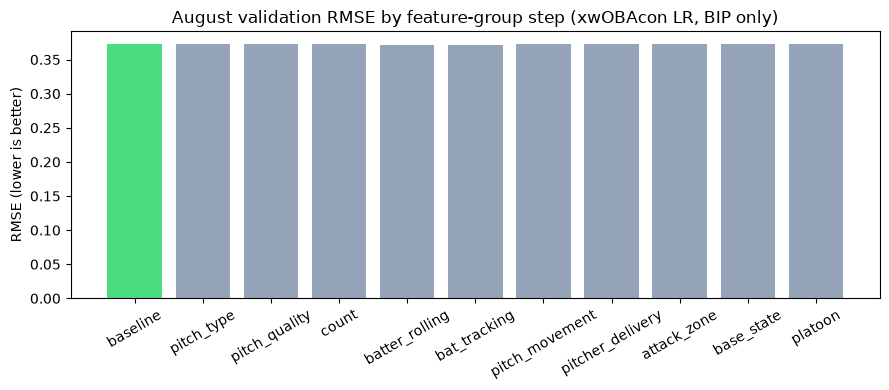

In [4]:
steps_df = pd.DataFrame(report.steps)
colors = ["#4ade80" if kept else "#94a3b8" for kept in steps_df["kept"]]

fig, ax = plt.subplots(figsize=(9, 4))
ax.bar(steps_df["step"], steps_df["val_rmse"], color=colors)
ax.set_title("August validation RMSE by feature-group step (xwOBAcon LR, BIP only)")
ax.set_ylabel("RMSE (lower is better)")
ax.tick_params(axis="x", rotation=30)
fig.tight_layout()
plt.show()


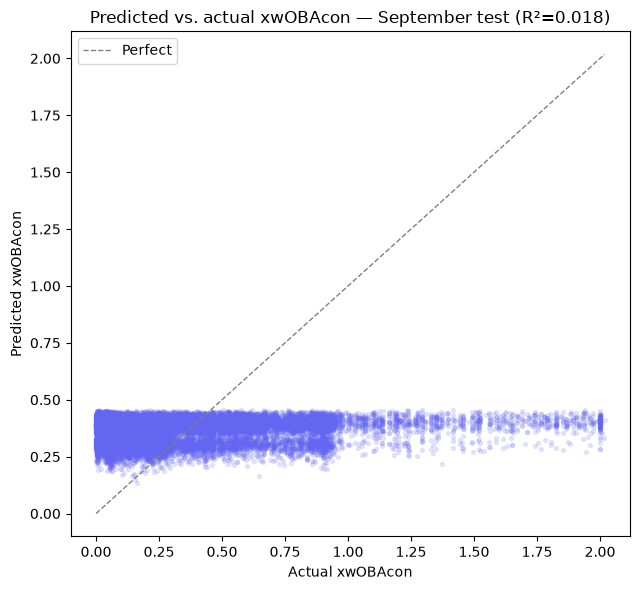

In [5]:
fig, ax = plt.subplots(figsize=(6.5, 6))
ax.scatter(master.y_test, master.y_pred_test, alpha=0.15, s=8, color="#6366f1")
lims = [0, max(master.y_test.max(), master.y_pred_test.max())]
ax.plot(lims, lims, "--", color="gray", linewidth=1, label="Perfect")
ax.set_title(f"Predicted vs. actual xwOBAcon — September test (R²={master.test_r2:.3f})")
ax.set_xlabel("Actual xwOBAcon")
ax.set_ylabel("Predicted xwOBAcon")
ax.legend(loc="upper left")
fig.tight_layout()
plt.show()


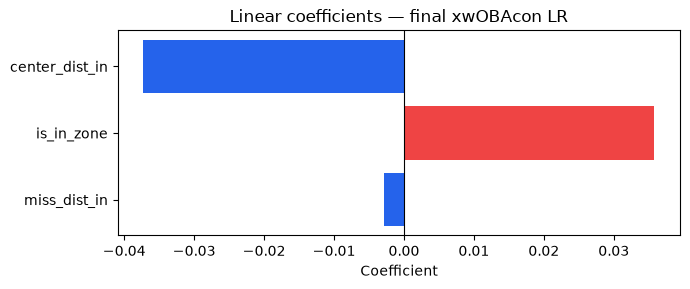

,feature,coefficient,abs_coef
0,center_dist_in,-0.037273,0.037273
1,is_in_zone,0.035815,0.035815
2,miss_dist_in,-0.002852,0.002852


In [6]:
coef = coefficient_frame(master)

fig, ax = plt.subplots(figsize=(7, max(3, 0.25 * len(coef))))
colors = ["#ef4444" if c > 0 else "#2563eb" for c in coef["coefficient"]]
ax.barh(coef["feature"][::-1], coef["coefficient"][::-1], color=colors[::-1])
ax.axvline(0, color="black", linewidth=0.8)
ax.set_title("Linear coefficients — final xwOBAcon LR")
ax.set_xlabel("Coefficient")
fig.tight_layout()
plt.show()

display(coef.head(20))


## 6. Summary

Compare September test RMSE/R² to **`09_modeling_xwobacon_rf.ipynb`**. Then continue to **`10_expected_value_engine.ipynb`**.